In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target
df['diagnosis_label'] = df['diagnosis'].map({0: 'Malignant', 1: 'Benign'})

print(df.shape)
df.head()

(569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


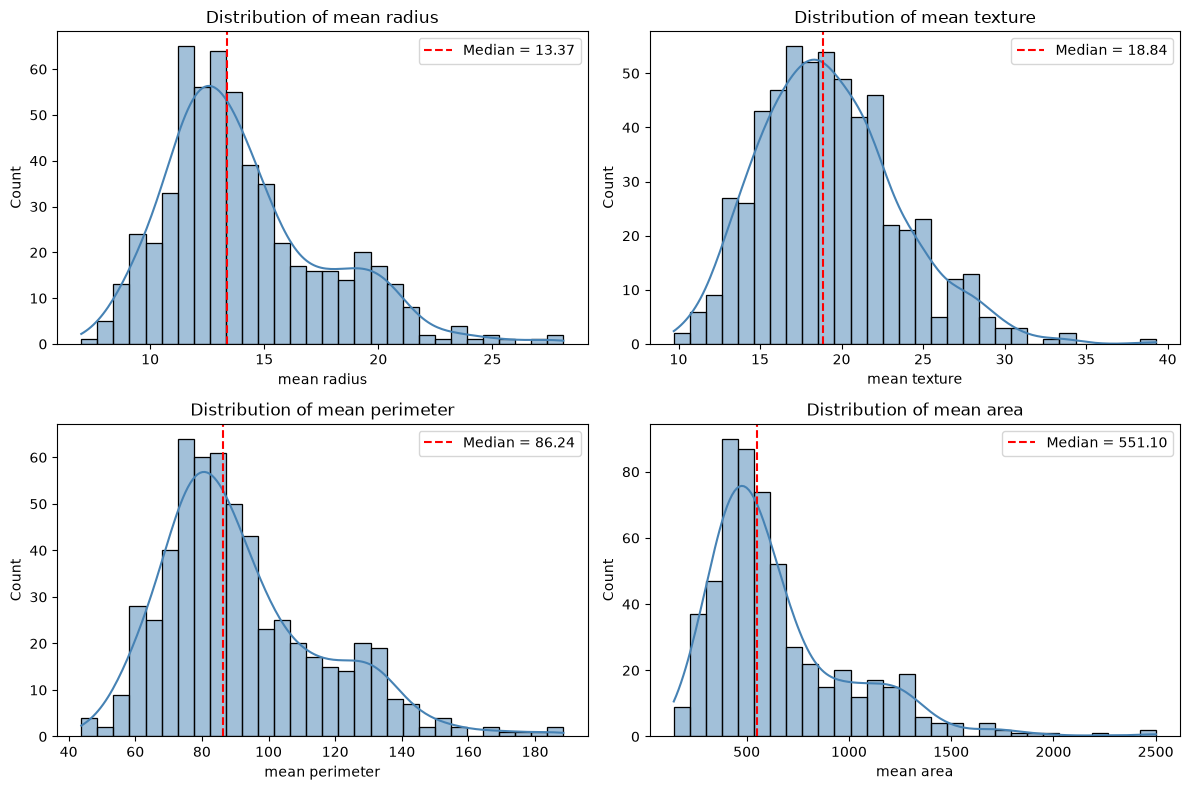

In [2]:
features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), features):
    sns.histplot(df[col], bins=30, kde=True, color='steelblue', ax=ax)
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'Median = {df[col].median():.2f}')
    ax.set_title(f'Distribution of {col}')
    ax.legend()

plt.tight_layout()
plt.show()

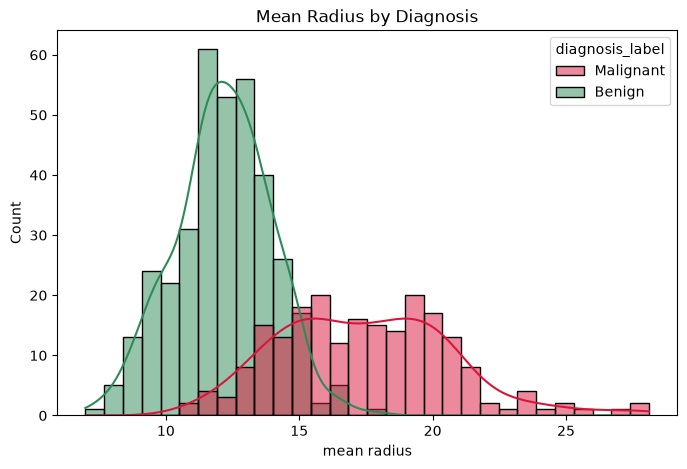

In [3]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='mean radius', hue='diagnosis_label', bins=30,
             kde=True, palette={'Malignant': 'crimson', 'Benign': 'seagreen'})
plt.title('Mean Radius by Diagnosis')
plt.show()

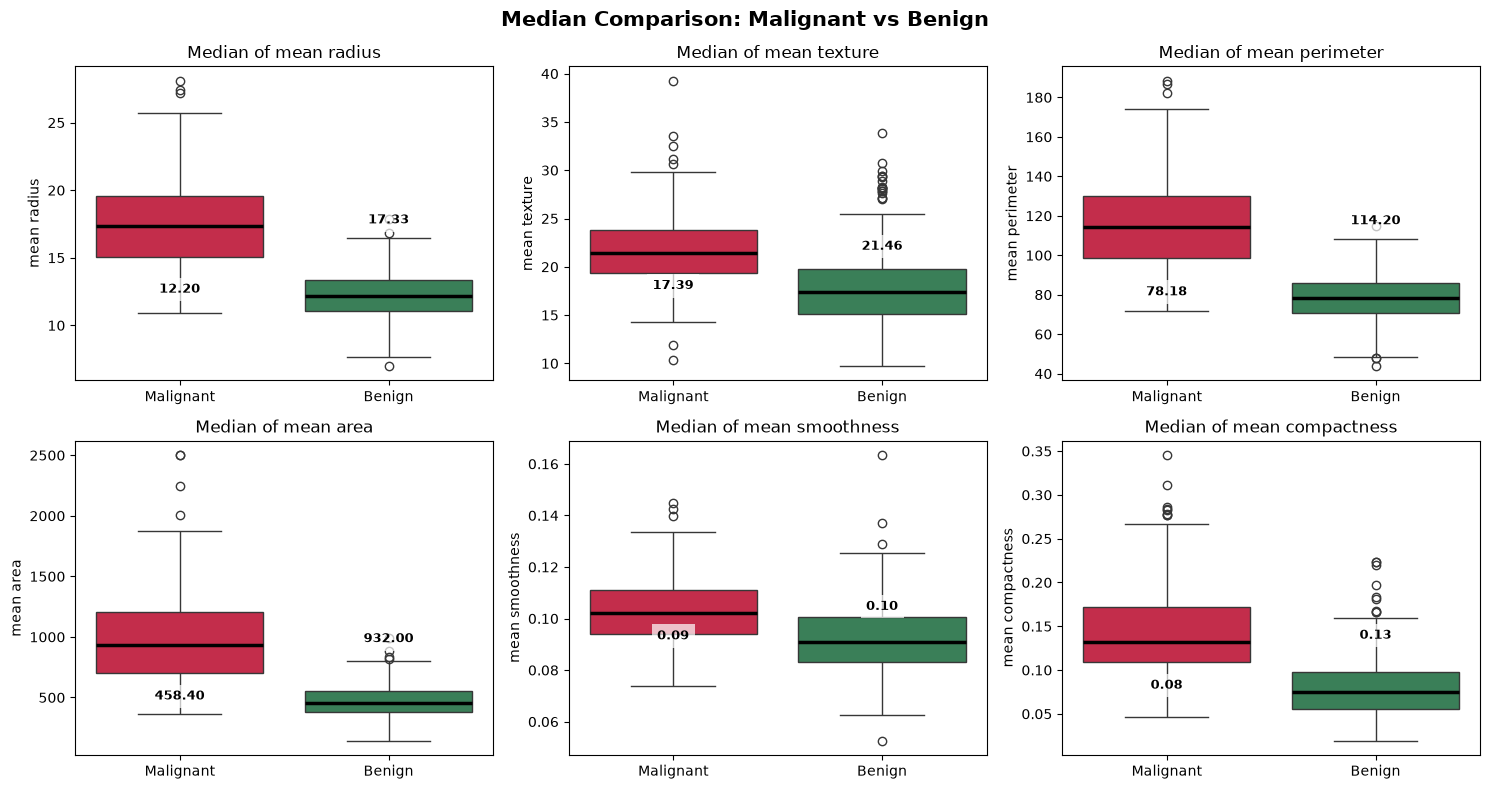

In [8]:
features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
            'mean smoothness', 'mean compactness']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='diagnosis_label', y=col, hue='diagnosis_label',
                legend=False, ax=ax,
                palette={'Malignant': 'crimson', 'Benign': 'seagreen'},
                medianprops={'color': 'black', 'linewidth': 2.5})

    # annotate the median value on each box
    medians = df.groupby('diagnosis_label')[col].median()
    for i, label in enumerate(['Benign', 'Malignant']):
        ax.text(i, medians[label], f'{medians[label]:.2f}',
                ha='center', va='bottom', fontweight='bold', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    ax.set_title(f'Median of {col}')
    ax.set_xlabel('')

plt.suptitle('Median Comparison: Malignant vs Benign', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

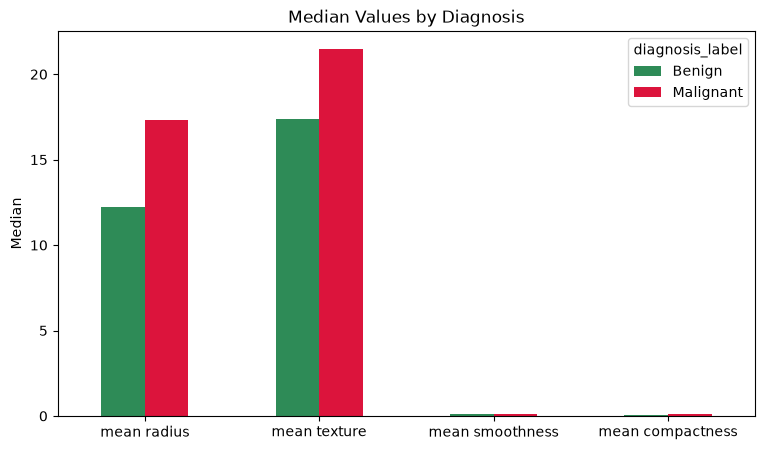

In [18]:
medians = df.groupby('diagnosis_label')[['mean radius', 'mean texture',
                                         'mean smoothness', 'mean compactness']].median().T

medians.plot(kind='bar', figsize=(9, 5), color=['seagreen', 'crimson'])
plt.title('Median Values by Diagnosis')
plt.ylabel('Median')
plt.xticks(rotation=0)
plt.show()

In [19]:
df.groupby('diagnosis_label')[data.feature_names[:10]].median().T.round(3)

diagnosis_label,Benign,Malignant
mean radius,12.200,17.325
mean texture,17.390,21.460
mean perimeter,78.180,114.200
mean area,458.400,932.000
mean smoothness,0.091,0.102
mean compactness,0.075,0.132
mean concavity,0.037,0.151
mean concave points,0.023,0.086
mean symmetry,0.171,0.190
mean fractal dimension,0.062,0.062
